# <center> Problem Statement </center>

The objective of this project is to develop a robust machine learning classification system to predict whether an individual earns more than $50K per year based on demographic and employment-related attributes.

The dataset includes features such as age, education, occupation, marital status, and working hours. The problem involves class imbalance, making it essential to focus on performance metrics beyond accuracy, such as F1-score and recall.

Multiple machine learning models, including ensemble and boosting techniques, are implemented and optimized using hyperparameter tuning. Techniques like class weighting and SMOTE are applied to handle imbalance and improve minority class prediction.

The final model aims to effectively identify high-income individuals, which can support data-driven decision-making in areas such as targeted marketing, financial analysis, and workforce insights.

# <center>Data Overview</center>

The dataset used in this project is the Income Classification dataset available on Kaggle. It contains demographic and employment-related information about individuals and their corresponding income category.

Dataset Characteristics

- Number of records: 32,561 individuals

- Number of features: 15 columns (including the target variable)

- Problem type: Binary Classification

- Target variable: income

The dataset contains both numerical and categorical features describing individuals such as their age, education level, occupation, marital status, and working hours. The goal is to analyze these attributes and build a predictive model that determines whether a person earns more than $50K annually.

# <center>Data Dictionary</center>

| Column         | Description                                                    |
| -------------- | -------------------------------------------------------------- |
| age            | Age of the individual                                          |
| workclass      | Type of employment (Private, Government, Self-employed, etc.)  |
| fnlwgt         | Final sampling weight assigned to the individual, number of people in the population that this record represents              |
| education      | Highest level of education attained                            |
| education-num  | Numeric representation of education level                      |
| marital-status | Marital status of the individual                               |
| occupation     | Type of job or occupation                                      |
| relationship   | Relationship status within the household                       |
| race           | Race category of the individual                                |
| sex            | Gender of the individual                                       |
| capital-gain   | Capital gains earned during the year                           |
| capital-loss   | Capital losses incurred during the year                        |
| hours-per-week | Number of hours worked per week                                |
| native-country | Country of origin of the individual                            |
| income         | Target variable indicating whether income is **>50K or <=50K** |


In [2]:
# Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

In [3]:
# Loading the dataset
df = pd.read_csv("income_evaluation.csv")

In [4]:
# top 5 rows
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
# Checking the shape
df.shape

(32561, 15)

In [6]:
# Checking the summary of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              32561 non-null  int64 
 1    workclass       32561 non-null  object
 2    fnlwgt          32561 non-null  int64 
 3    education       32561 non-null  object
 4    education-num   32561 non-null  int64 
 5    marital-status  32561 non-null  object
 6    occupation      32561 non-null  object
 7    relationship    32561 non-null  object
 8    race            32561 non-null  object
 9    sex             32561 non-null  object
 10   capital-gain    32561 non-null  int64 
 11   capital-loss    32561 non-null  int64 
 12   hours-per-week  32561 non-null  int64 
 13   native-country  32561 non-null  object
 14   income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


interpretation:

- This showing our dataset doesn't have any null value.
- 6 columns with Dtype 'int64' and 9 columns with Dtype 'object'.

In [7]:
# Checking the statistical summary of numerical features
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


Interpretation:

age
- The average age of an individual in the dataset is 38.5.
- The youngest individual is of 17 years whereas the oldest individual is of 90 years.
- Around 50% of individual is in age group between 28 years to 48 years.
- 50% of individual are 37 years old or younger.

Insight:
The dataset mostly contains the working-age adults, which is obvious only.

fnlwgt
- The average of final sampling weight is 1,89,778.
- The lowest weight is 12,285 whereas the highest weight is 14,84,705.

Insight:
I think this feature is meaningless for modelling income prediction because a sample weight is not useful for income prediction.

education-num
- The average education level of individual is 10.08 i.e. around some-college as per dataset.
- The range is from 1 to 16, where 16 is the highest level of education.
- The median value is 10, means most individual have a some-college level

Insight:
This education-num may be a strong feature for predicting the income.

capital-gain
- The average capital gain of individuals is 1077.6 whereas median is 0.
- The highest capital gain is 99,999 lead to an extreme outlier because most of the individuals doesn't have any capital gain.

Insight:
The feature is highly skewed we can say because most of the individual have 0 capital gain.

capital-loss
- The average capital loss of individuals is 87.30 whereas median is 0.
- The highest capital loss is 4,356 lead to an extreme outlier because most of the individuals doesn't have any capital loss.

Insight:
The feature is highly skewed we can say because most of the individual have 0 capital loss.

hours-per-week
- The average working hours per week is 40.44 hours.
- The minimum is 1 hour, and the maximum is 99 hours.
- The median value is 40 hours, which indicates that most individuals work around full-time hours i.e. 8 hours per day.
- 75% of individuals work 45 hours or less per week.

Insight:
This is also an important feature maybe more the working hours more the income of the individuals.


In [8]:
# Checking the statistical summary of categorical features
df.describe(include='object').T

,count,unique,top,freq
workclass,32561,9,Private,22696
education,32561,16,HS-grad,10501
marital-status,32561,7,Married-civ-spouse,14976
occupation,32561,15,Prof-specialty,4140
relationship,32561,6,Husband,13193
race,32561,5,White,27816
sex,32561,2,Male,21790
native-country,32561,42,United-States,29170
income,32561,2,<=50K,24720


Interpretation:

Workclass

- The dataset contains 9 different types of workclass categories.
- The most common category is Private, with 22,696 individuals.

Insight:
Most individuals in the dataset works in the private sector.

Education

- There are 16 different education levels in the dataset.
- The most frequent education level is HS-grad, with 10,501 individuals.

Insight:
A large portion of individuals in the dataset have high school level education.

Marital Status

- The dataset contains 7 marital status categories.
- The most common category is Married-civ-spouse, with 14,976 individuals.

Insight:
Many individuals in the dataset are married.

Occupation

- There are 15 different occupation types.
- The most frequent occupation is Prof-specialty, with 4,140 individuals.

Insight:
Professional specialty jobs appear to be the most common occupation in the dataset.

Relationship

- The dataset contains 6 relationship categories.
- The most common relationship category is Husband, with 13,193 individuals.

Insight:
This indicates that many individuals in the dataset are recorded as husbands.

Race

- There are 5 race categories in the dataset.
- The most common category is White, with 27,816 individuals.

Insight:
The dataset is heavily dominated by one race category, which may lead to class imbalance in this feature.

Sex

- The dataset contains 2 gender categories.
- The majority are Male, with 21,790 individuals.

Insight:
The dataset contains more male individuals than female individuals.

Native Country

- There are 42 different countries represented in the dataset.
- The most common country is United States, with 29,170 individuals.

Insight:
Most individuals in the dataset are from the United States, meaning other countries appear much less frequently.

Income (Target Variable)

- The dataset has 2 income categories:

<=50K

\>50K
- The majority of individuals (24,720) earn <=50K.

Insight:
Maybe the target variable is imbalanced because most of the individual fall under <=50 category.

In [9]:
# Checking the columns name
df.columns

Index(['age', ' workclass', ' fnlwgt', ' education', ' education-num',
       ' marital-status', ' occupation', ' relationship', ' race', ' sex',
       ' capital-gain', ' capital-loss', ' hours-per-week', ' native-country',
       ' income'],
      dtype='object')

Interpretaion:

Some columns name have leading spaces and "-" in between, so i will remove the leading spaces and replace "-" with "_".

In [10]:
# Cleaning the columns name
df.columns = (
    df.columns
    .str.lstrip()
    .str.replace("-", "_")
)
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='object')

In [11]:
# Checking for duplicates
df.duplicated().sum()

np.int64(24)

Interpretation:

We have 24 duplicated records of individuals, so we simply remove that

In [12]:
# Removing the duplicated rows
df.drop_duplicates(inplace=True)

In [13]:
# Now Checking the shapes of dataset
df.shape

(32537, 15)

Interpretation:

After removing duplicated rows, we are left with 32,537 individual's samples in the dataset.

In [14]:
# Creating a list of num_cols and cat_cols
num_cols = df.select_dtypes(include='number').columns.to_list()
cat_cols = df.select_dtypes(exclude='number').columns.to_list()
print(f"Total Numerical columns we have {len(num_cols)} i.e. {num_cols}")
print(f"Total Categorical columns we have {len(cat_cols)} i.e. {cat_cols}")

Total Numerical columns we have 6 i.e. ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
Total Categorical columns we have 9 i.e. ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'income']


# <center>Univariate Analysis</center>

In [15]:
# Checking the unique categories in categorical columns
for col in cat_cols:
    print('--------------------------------------------')
    print(f'Column: {col}')
    print(f'Number of unique values: {df[col].nunique()}')
    print(df[col].value_counts().head(10))
print('--------------------------------------------')

--------------------------------------------
Column: workclass
Number of unique values: 9
workclass
Private             22673
Self-emp-not-inc     2540
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64
--------------------------------------------
Column: education
Number of unique values: 16
education
HS-grad         10494
Some-college     7282
Bachelors        5353
Masters          1722
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           645
Prof-school       576
Name: count, dtype: int64
--------------------------------------------
Column: marital_status
Number of unique values: 7
marital_status
Married-civ-spouse       14970
Never-married            10667
Divorced                  4441
Separated                 1025
Widowed                    993
Married-spouse-absent      4

Interpretaion:

I notice one unkonwn category i.e. ? in three columns i.e. "native_country", "occupation", "workclass". So we will replace this '?' with null.

In [16]:
# Checking for "?" in the columns
(df=="?").sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [17]:
# Removing the leading and trailing spaces from all the columns category
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

In [18]:
# replacing the " ?" with nan
df.replace("?", np.nan, inplace=True)

In [19]:
# Now checking for null values in the columns
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     582
income               0
dtype: int64

In [20]:
# Checking how many rows have null values
print("Rows before removing nulls:", df.shape[0])
print("Rows after removing nulls:", df.dropna().shape[0])
print("Rows that will be removed:", df.shape[0] - df.dropna().shape[0])

Rows before removing nulls: 32537
Rows after removing nulls: 30139
Rows that will be removed: 2398


Interpretation:

we have 2398 rows that will be remove, its around 7.37% of the dataset. So, i will remove this and move forward

In [21]:
# Removing the rows having null from the dataset
df.dropna(inplace = True)

In [22]:
# Checking the shape of dataset
df.shape

(30139, 15)

In [23]:
# Again checking the unique categories in categorical columns after removing " ?"
for col in cat_cols:
    print('--------------------------------------------')
    print(f'Column: {col}')
    print(f'Number of unique values: {df[col].nunique()}')
    print(df[col].value_counts().head(10))
print('--------------------------------------------')

--------------------------------------------
Column: workclass
Number of unique values: 7
workclass
Private             22264
Self-emp-not-inc     2498
Local-gov            2067
State-gov            1279
Self-emp-inc         1074
Federal-gov           943
Without-pay            14
Name: count, dtype: int64
--------------------------------------------
Column: education
Number of unique values: 16
education
HS-grad         9834
Some-college    6669
Bachelors       5042
Masters         1626
Assoc-voc       1307
11th            1048
Assoc-acdm      1008
10th             820
7th-8th          556
Prof-school      542
Name: count, dtype: int64
--------------------------------------------
Column: marital_status
Number of unique values: 7
marital_status
Married-civ-spouse       14059
Never-married             9711
Divorced                  4212
Separated                  939
Widowed                    827
Married-spouse-absent      370
Married-AF-spouse           21
Name: count, dtype: int64
--

Interpretation:

Now all the categories are looking fine, but maybe we have slightly imbalanced target column i.e. 'income'.

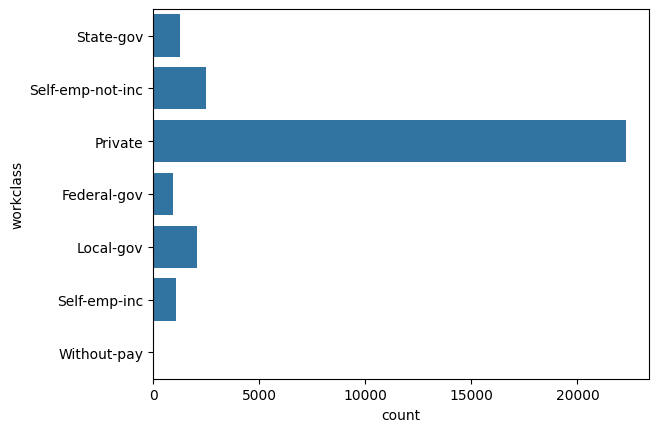

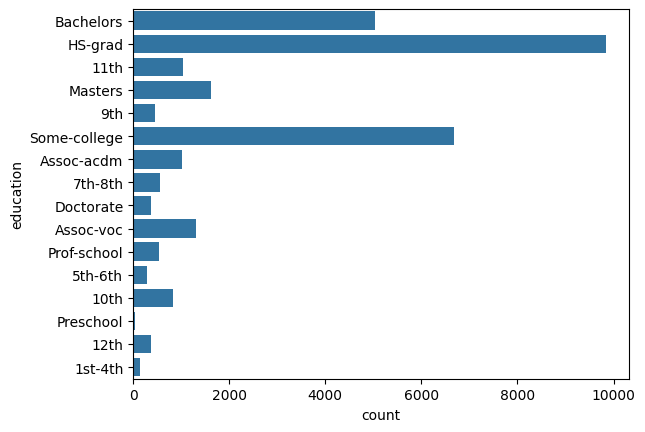

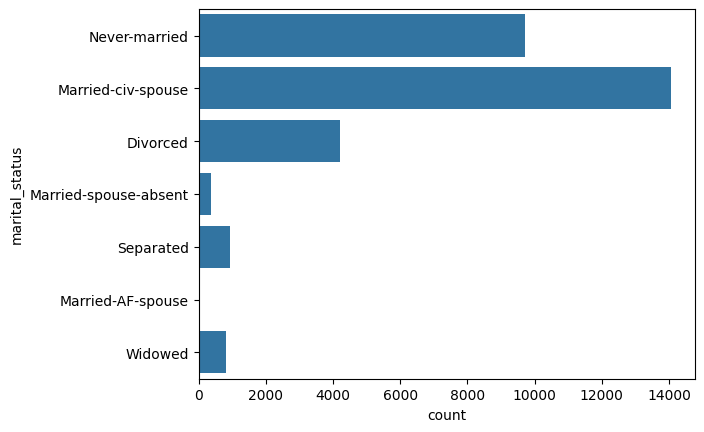

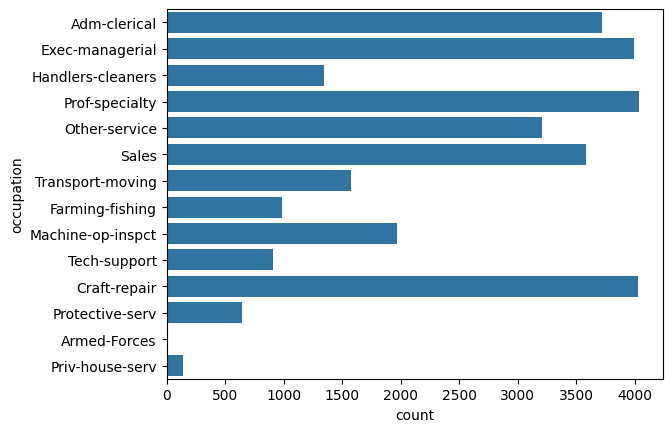

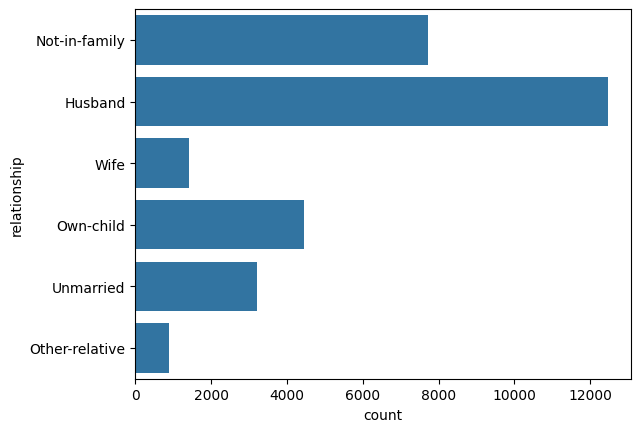

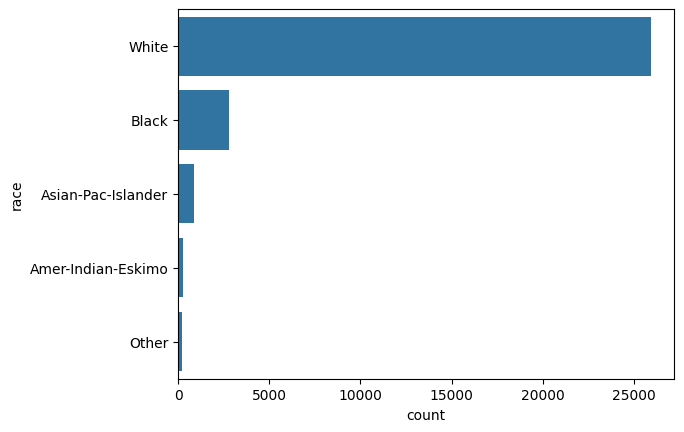

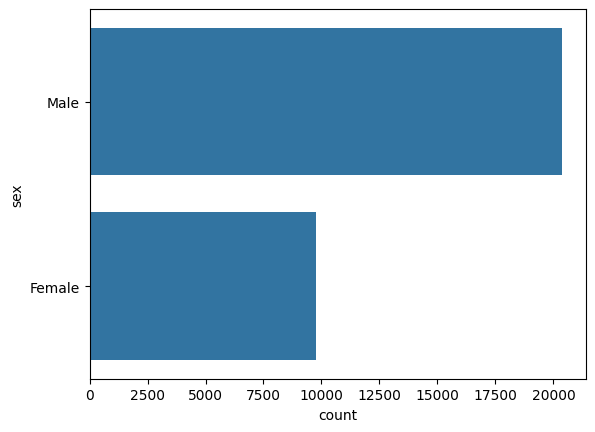

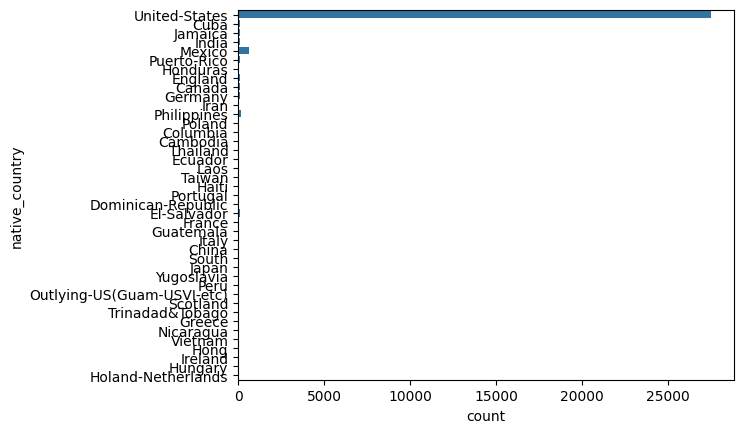

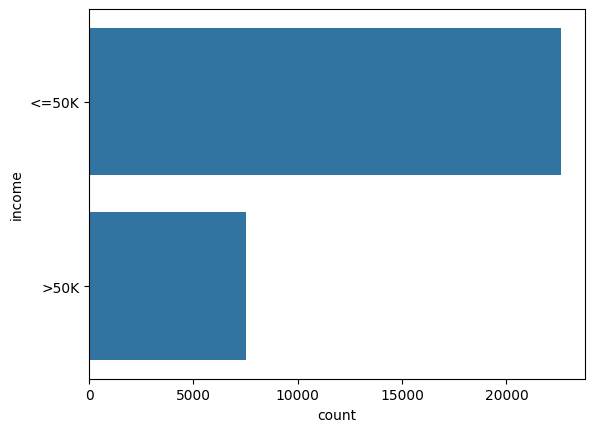

In [24]:
# Checking the countplot of categorical variables
for col in cat_cols:
    sns.countplot(df[col])
    plt.show()

In [25]:
# Checking the category wise percentage in target variable
counts = df['income'].value_counts()
percentage = df['income'].value_counts(normalize=True) * 100

result = pd.DataFrame({
    'Count': counts,
    'Percentage': percentage
})

print(result)

        Count  Percentage
income                   
<=50K   22633   75.095391
>50K     7506   24.904609


Interpretation:

we have around 75:25 ratio of category in the target variable, its slightly imbalanced

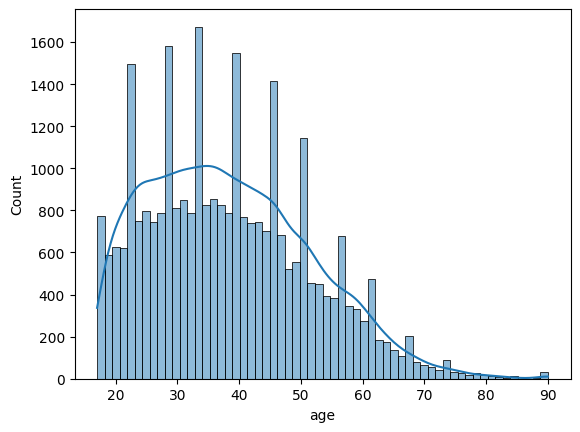

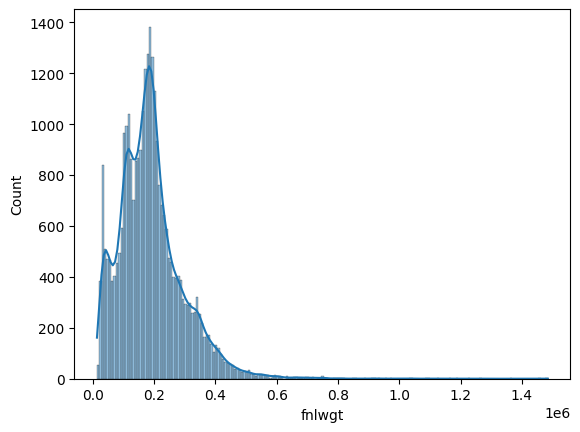

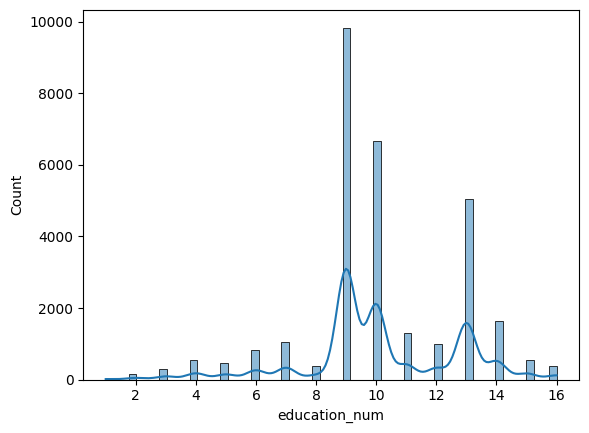

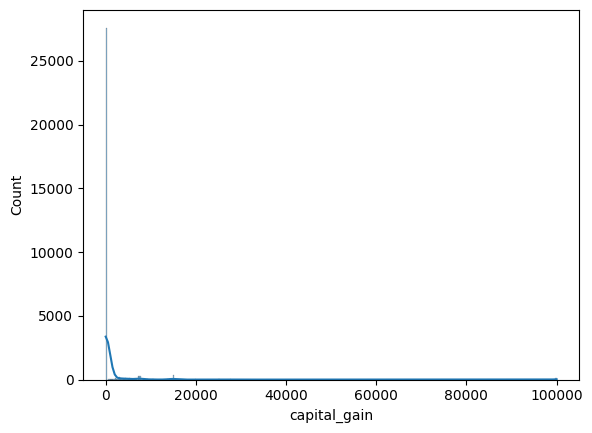

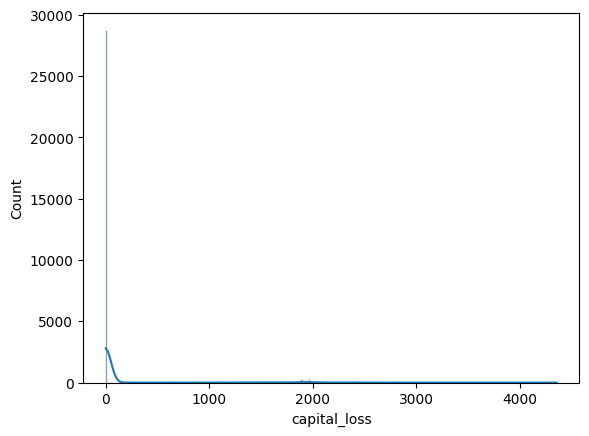

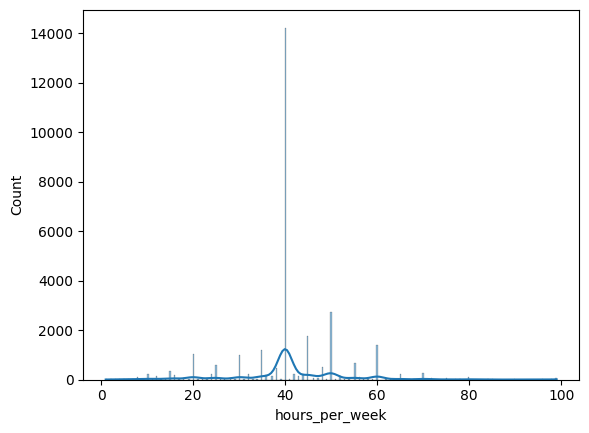

In [26]:
# Checking the distribution of numerical variables
for col in num_cols:
    sns.histplot(df[col],kde=True)
    plt.show()

Interpretation:

- education_num and hours_per_week are two features which have approximately normal distribution.
- age variable is also approximately normally distributed but large value outliers are exists.
- fnlwgt, capital_gain, capital_loss we can say these features are highly skewed. As we notices earlier also because most of the individuals have 0 capital loss or gain.

We will treat the skewness later by using some transformation techniques.

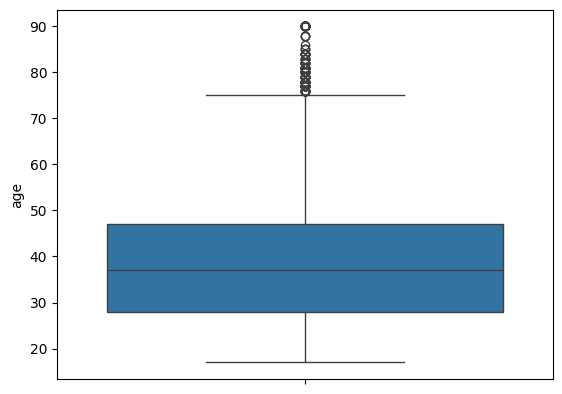

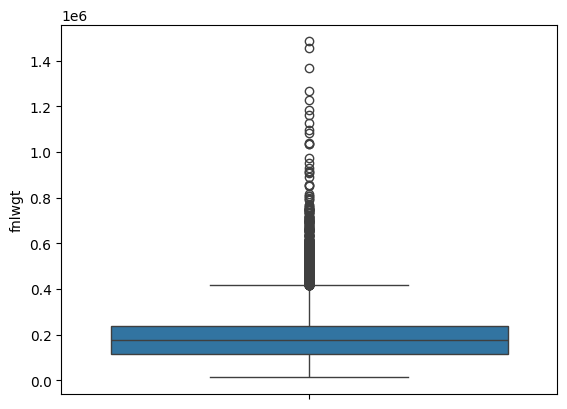

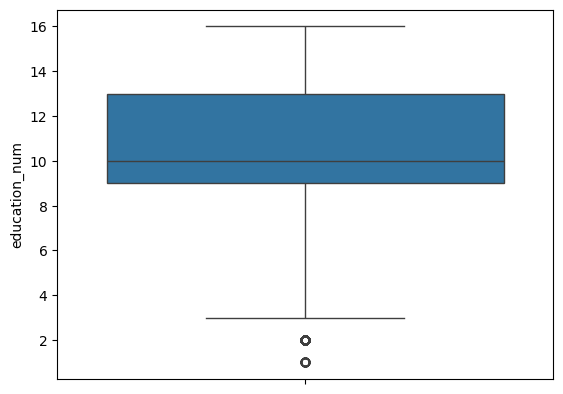

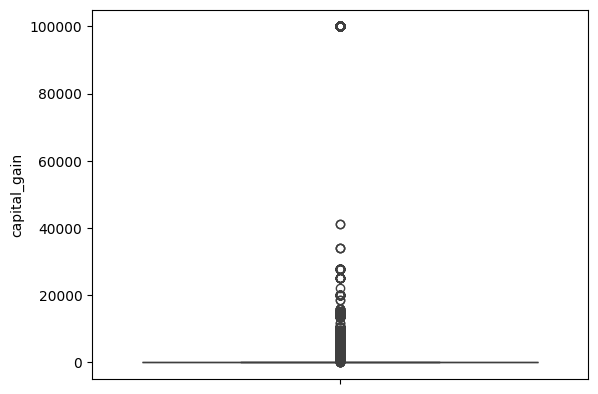

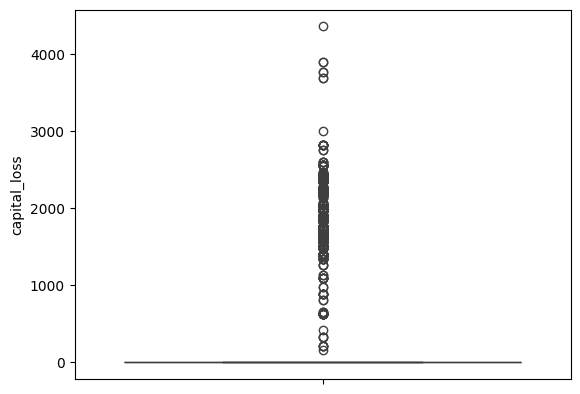

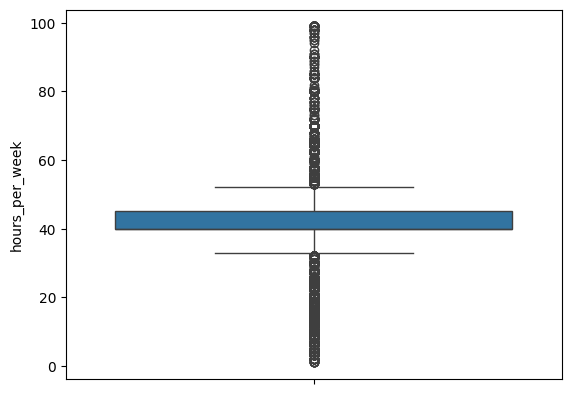

In [27]:
# Checking the outliers using Box plot
for col in num_cols:
    sns.boxplot(df[col])
    plt.show()

Interpretation:

- We have outliers among all the numerical features, its not required to remove the outliers because here outliers carry meaningful information that's why instead of deleting or winsorization the outliers we will try transformation techinques to reduce the effect of extreme outliers or we will use tree based models because they are independent of outliers.

In [28]:
# Checking the skewness of numerical cols
df[num_cols].skew().sort_values(ascending=False)

capital_gain      11.898104
capital_loss       4.524409
fnlwgt             1.460055
age                0.528971
hours_per_week     0.332386
education_num     -0.302845
dtype: float64

Interpretation:

- We have highly skewed columns because of extreme outliers in some columns

# <center>Bivariate Analysis</center>

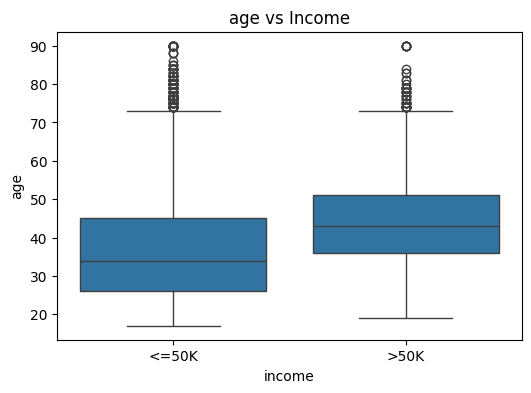

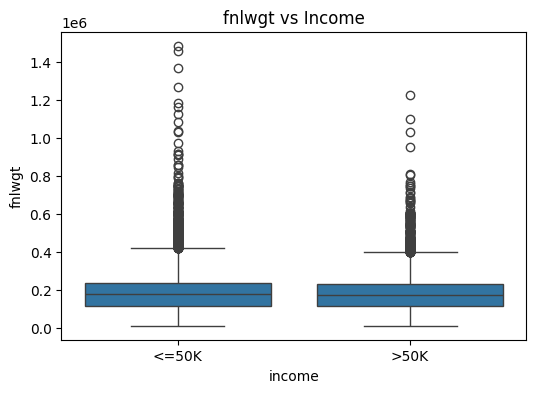

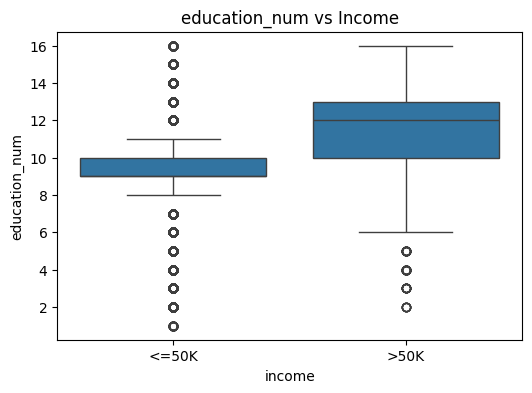

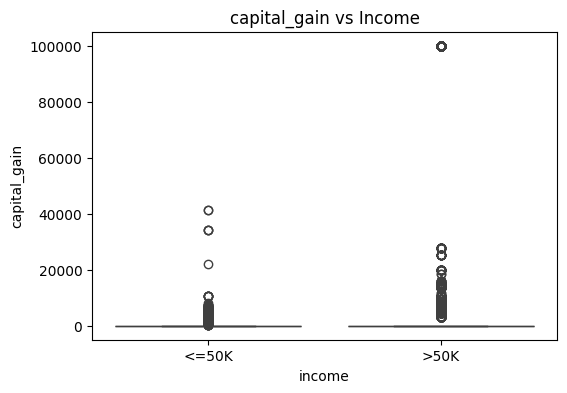

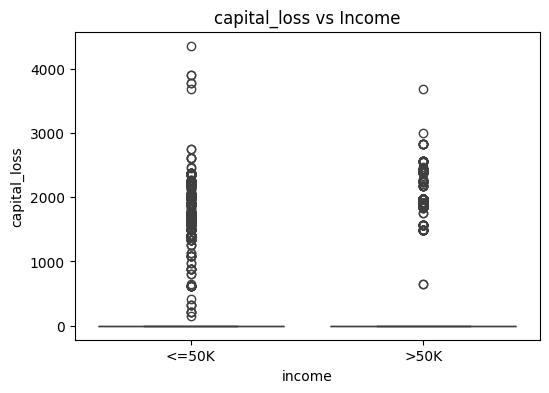

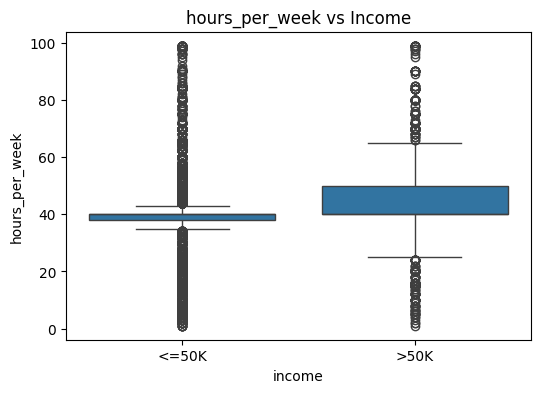

In [29]:
# Numerical Features Vs Categorical Target
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='income', y=col, data=df)
    plt.title(f'{col} vs Income')
    plt.show()

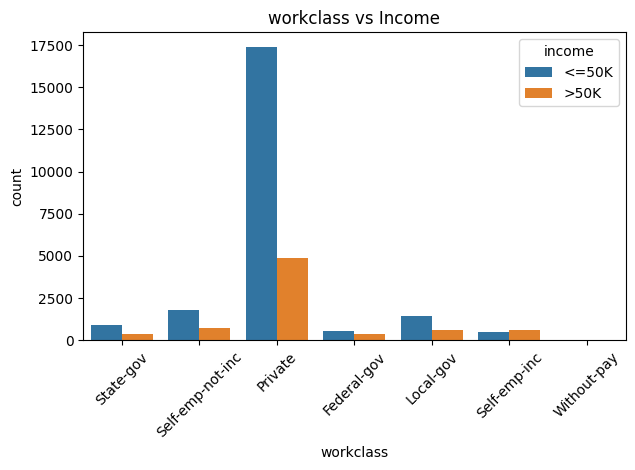

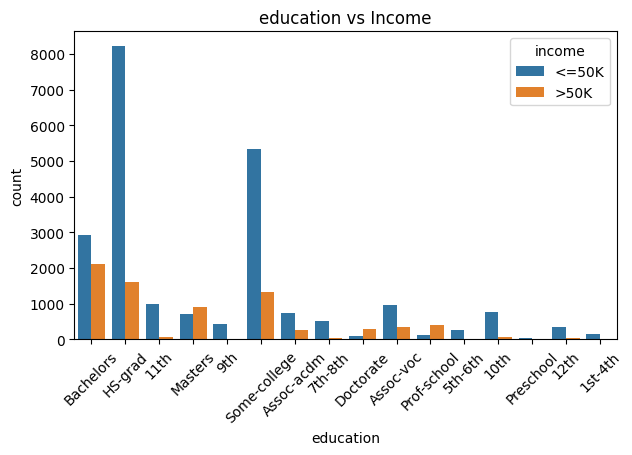

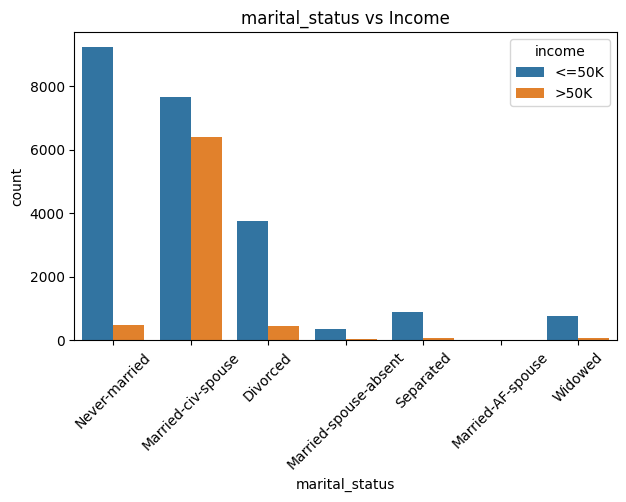

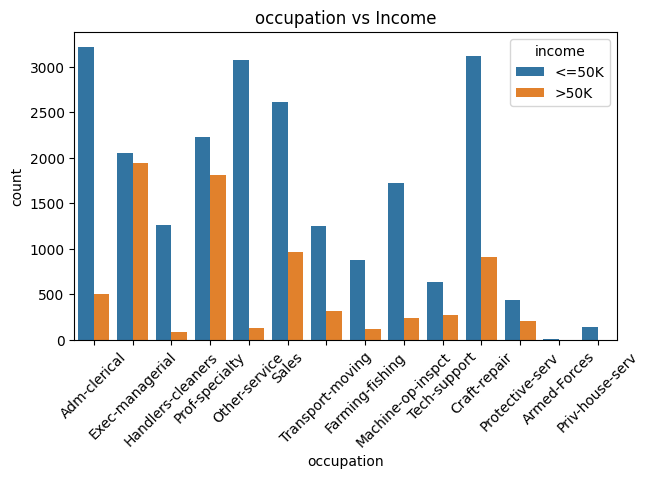

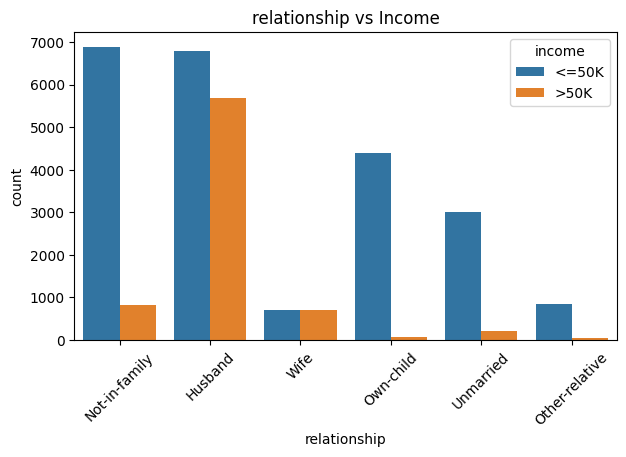

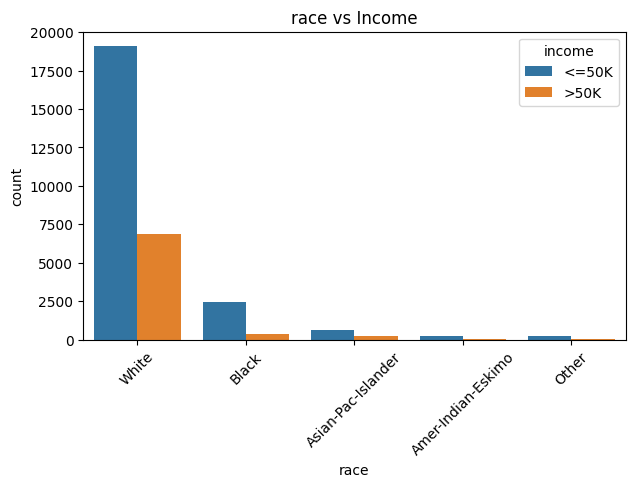

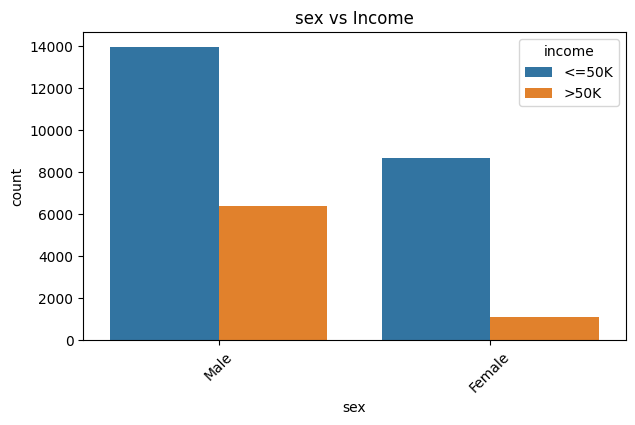

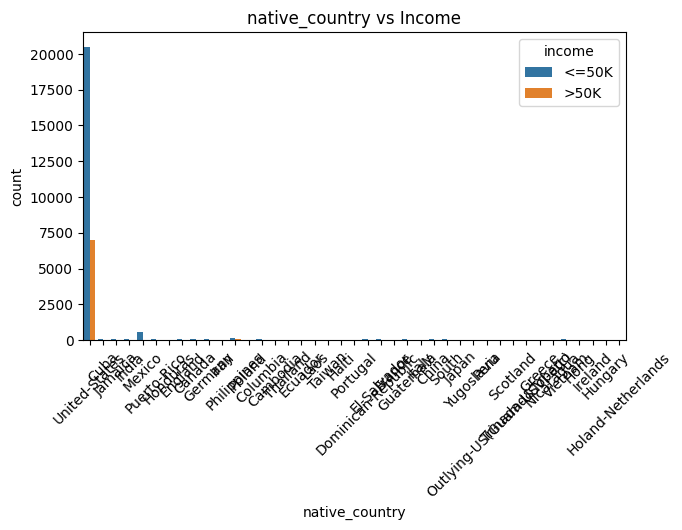

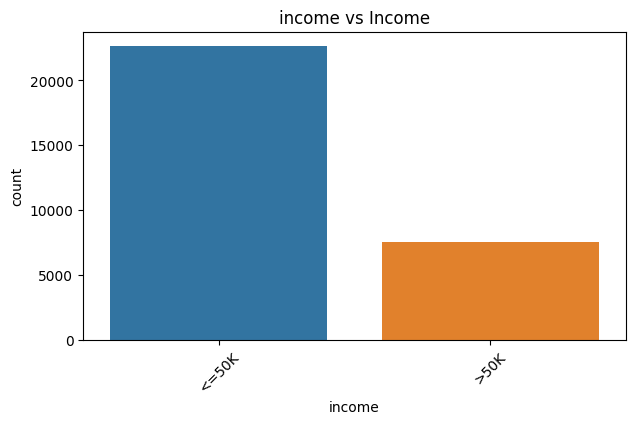

In [30]:
for col in cat_cols:
    plt.figure(figsize=(7,4))
    sns.countplot(x=col, hue='income', data=df)
    plt.xticks(rotation=45)
    plt.title(f'{col} vs Income')
    plt.show()

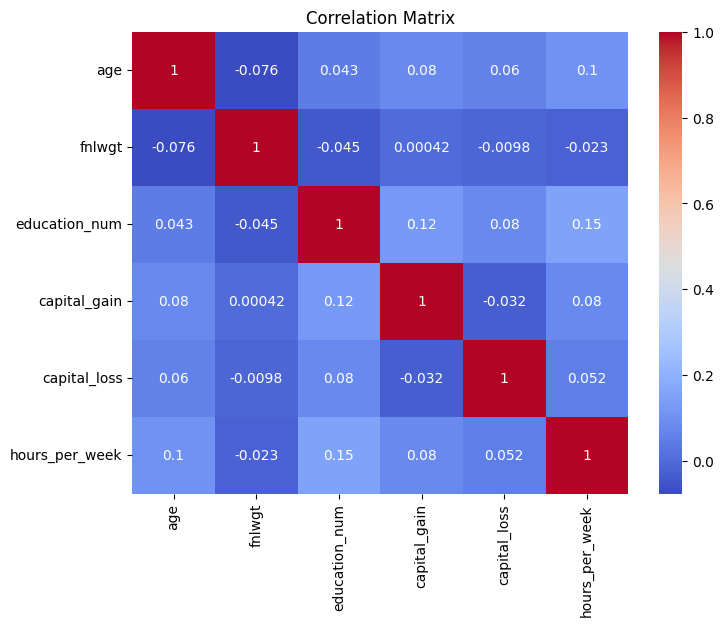

In [31]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# <center> TrainTest Split</center>

In [33]:
X = df.drop('income', axis=1)
# Changing the labels of target variable into numerical
y = df['income'].map({"<=50K":0, ">50K":1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# <center>Baseline Model</center>

In [35]:
# Creating Baseline Model
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Selecting cat_cols and num_cols for preprocessing
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(exclude='object').columns.tolist()

# Using ColumnTransformer Doing the preprocessing
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ("num", StandardScaler(), num_cols)
])

# Creating a dictionary of models
models = {
    "LogisticRegression": LogisticRegression(),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "XGBoost": XGBClassifier(),
    "GradientBoost": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier()
}

# Creating a empty list of baseline_results
baseline_result = []

# Loop for training and testing different models
for name, model in models.items():

    print(f"\n🔍 Training {name}...")

    pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', model)
])

    pipeline.fit(X_train, y_train)

    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    # Metrics
    baseline_result.append({
        "Model": name,

        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Train Precision": precision_score(y_train, y_train_pred),
        "Train Recall": recall_score(y_train, y_train_pred),
        "Train F1": f1_score(y_train, y_train_pred),

        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Test Precision": precision_score(y_test, y_test_pred),
        "Test Recall": recall_score(y_test, y_test_pred),
        "Test F1": f1_score(y_test, y_test_pred),
    }
    )

baseline_result_df = pd.DataFrame(baseline_result)
baseline_result_df = baseline_result_df.sort_values(by="Test F1", ascending=False)

baseline_result_df


🔍 Training LogisticRegression...

🔍 Training DecisionTree...

🔍 Training RandomForest...

🔍 Training KNN...

🔍 Training SVM...

🔍 Training XGBoost...

🔍 Training GradientBoost...

🔍 Training AdaBoost...


,Model,Train Accuracy,Train Precision,Train Recall,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1
5,XGBoost,0.905354,0.854419,0.744089,0.795446,0.871267,0.791635,0.674660,0.728481
2,RandomForest,0.999917,1.000000,0.999665,0.999832,0.857332,0.760488,0.646144,0.698669
6,GradientBoost,0.865580,0.796902,0.612611,0.692709,0.863802,0.815009,0.605314,0.694682
0,LogisticRegression,0.849405,0.739032,0.604561,0.665068,0.851194,0.757987,0.615036,0.679070
4,SVM,0.863548,0.788848,0.612108,0.689330,0.852356,0.777400,0.593001,0.672794
7,AdaBoost,0.849737,0.769213,0.560624,0.648560,0.850199,0.788809,0.566429,0.659374
3,KNN,0.879142,0.786614,0.701660,0.741712,0.833444,0.696000,0.620220,0.655929
1,DecisionTree,0.999959,1.000000,0.999832,0.999916,0.811048,0.630829,0.631238,0.631033


XGBoost is clearly the top performing baseline model with
- Test F1: 0.728 (Highest)

- Balanced precision (0.79) and recall (0.67)

- Good generalization (train vs test not too far)

# <center> Preprocessing Pipeline with Hyperparameter Tuning </center>

In [ ]:
# Selective Preprocessing Pipeline with Skewness Handling and Hyperparameter Tuning for Logistic Regression, Support Vector Classifier, K Nearest Neighbors
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer

from sklearn.model_selection import GridSearchCV

# Selecting cat_cols and num_cols for different preprocessing
num_cols = X_train.select_dtypes(exclude='object').columns.to_list()
cat_cols = X_train.select_dtypes(include='object').columns.to_list()

# Further dividing num_cols into skewed_cols and non_skewed_cols
skewness = X_train[num_cols].skew()
skewed_cols = skewness[abs(skewness)>0.5].index.to_list()
non_skewed_cols = skewness[abs(skewness)<=0.5].index.to_list()

# Creating different pipeline for skewed_cols and non_skewed_cols
skewed_pipeline = Pipeline([
    ('power', PowerTransformer(method='yeo-johnson')),
    ('scaler', StandardScaler())
])

non_skewed_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

# for avoiding empty column issues for preprocessor
transformers=[]

if len(cat_cols)>0:
    transformers.append(('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols))

if len(skewed_cols)>0:
    transformers.append(('skewed_num', skewed_pipeline, skewed_cols))

if len(non_skewed_cols)>0:
    transformers.append(('non_skewed_num', non_skewed_pipeline, non_skewed_cols))

# preprocessor
preprocessor = ColumnTransformer(transformers)

# Creating a dictionary of models and param_grid for hyperparameter tuning
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "SVC": SVC(class_weight='balanced', probability=True, random_state=42),
    "KNN": KNeighborsClassifier()
}

param_grid = {
    'LogisticRegression':{
        "model__C": [0.01, 0.1, 1, 10],
        "model__solver": ["lbfgs", "liblinear"]
    },

    'SVC':{
        "model__C": [0.1, 1, 10],
        "model__kernel": ["linear", "rbf"],
        "model__gamma": ["scale", "auto"]
    },
    'KNN':{
    "model__n_neighbors": [3, 5, 7, 9, 11],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2],  # 1 = Manhattan, 2 = Euclidean
    "model__algorithm": ["auto", "ball_tree", "kd_tree"]
    }
}

# best_models
linear_distance_best_models = {}
# result
linear_distance_result=[]

# Loop for training and testing of different models
for name, model in models.items():
    print(f"\n🔍 Training {name}...")

    pipeline=Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    grid = GridSearchCV(
        pipeline,
        param_grid[name],
        cv=5,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    linear_distance_best_models[name]=best_model

    print("Best Params:", grid.best_params_)

    y_test_pred = best_model.predict(X_test)
    y_train_pred = best_model.predict(X_train)

    #Metrics
    linear_distance_result.append({
        "Model": name,

        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Train Precision": precision_score(y_train, y_train_pred, zero_division=0),
        "Train Recall": recall_score(y_train, y_train_pred, zero_division=0),
        "Train F1": f1_score(y_train, y_train_pred, zero_division=0),

        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Test Precision": precision_score(y_test, y_test_pred, zero_division=0),
        "Test Recall": recall_score(y_test, y_test_pred, zero_division=0),
        "Test F1": f1_score(y_test, y_test_pred, zero_division=0),
    }
    )

# Converting result into dataframe
linear_distance_result_df = pd.DataFrame(linear_distance_result)
linear_distance_result_df = linear_distance_result_df.sort_values(by="Test F1", ascending=False)

# final linear_distance_result_df
linear_distance_result_df


🔍 Training LogisticRegression...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Params: {'model__C': 10, 'model__solver': 'lbfgs'}

🔍 Training SVC...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Params: {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}

🔍 Training KNN...
Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best Params: {'model__algorithm': 'auto', 'model__n_neighbors': 11, 'model__p': 1, 'model__weights': 'uniform'}


,Model,Train Accuracy,Train Precision,Train Recall,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1
1,SVC,0.807059,0.570583,0.888647,0.694951,0.805242,0.579151,0.874919,0.696954
0,LogisticRegression,0.802829,0.568328,0.843200,0.679001,0.808394,0.587703,0.842515,0.692410
2,KNN,0.856539,0.727306,0.671809,0.698457,0.837259,0.698166,0.641607,0.668693


In [ ]:
# Selective Preprocessing Pipeline with Hyperparameter Tuning for Tree-based Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import GridSearchCV

# Selecting cat_cols and num_cols for different preprocessing
num_cols = X_train.select_dtypes(exclude='object').columns.to_list()
cat_cols = X_train.select_dtypes(include='object').columns.to_list()

# preprocessor
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('num', 'passthrough', num_cols)
])

# For XGBoost calculating the scale_pos_weight i.e. (number of negative samples)/(number of positive samples)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Creating a dictionary of models and param_grid for hyperparameter tuning
models = {
    "DecisionTree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "RandomForest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "GradientBoost": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42, scale_pos_weight=scale_pos_weight)
}

# Param grids
param_grid = {
    "DecisionTree": {
        "model__max_depth": [5, 10, 15, None],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    },

    "RandomForest": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [10, 20, None],
        "model__min_samples_split": [2, 5]
    },

    "GradientBoost": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.01, 0.1],
        "model__max_depth": [3, 5]
    },

    "XGBoost": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.01, 0.1],
        "model__max_depth": [3, 5, 7],
        "model__subsample": [0.8, 1]
    }
}


# best_models
tree_based_best_models={}
# result
tree_based_result=[]

# Loop for training and testing of different models
for name, model in models.items():
    print(f"\n🔍 Training {name}...")

    pipeline=Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    grid = GridSearchCV(
        pipeline,
        param_grid[name],
        cv=5,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    tree_based_best_models[name]=best_model

    print("Best Params:", grid.best_params_)

    y_test_pred = best_model.predict(X_test)
    y_train_pred = best_model.predict(X_train)

    #Metrics
    tree_based_result.append({
        "Model": name,

        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Train Precision": precision_score(y_train, y_train_pred, zero_division=0),
        "Train Recall": recall_score(y_train, y_train_pred, zero_division=0),
        "Train F1": f1_score(y_train, y_train_pred, zero_division=0),

        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Test Precision": precision_score(y_test, y_test_pred, zero_division=0),
        "Test Recall": recall_score(y_test, y_test_pred, zero_division=0),
        "Test F1": f1_score(y_test, y_test_pred, zero_division=0),
    }
    )

# Converting result into dataframe
tree_based_result_df = pd.DataFrame(tree_based_result)
tree_based_result_df = tree_based_result_df.sort_values(by="Test F1", ascending=False)

# final tree_based_result_df
tree_based_result_df


🔍 Training DecisionTree...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Params: {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10}

🔍 Training RandomForest...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Params: {'model__max_depth': 20, 'model__min_samples_split': 5, 'model__n_estimators': 100}

🔍 Training GradientBoost...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Params: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}

🔍 Training XGBoost...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Params: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__subsample': 0.8}


,Model,Train Accuracy,Train Precision,Train Recall,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1
3,XGBoost,0.856414,0.650717,0.905417,0.757223,0.837923,0.633996,0.867790,0.732695
2,GradientBoost,0.895525,0.839511,0.714070,0.771726,0.871102,0.797823,0.664938,0.725345
1,RandomForest,0.880221,0.690261,0.935435,0.794361,0.836264,0.636811,0.838626,0.723916
0,DecisionTree,0.816930,0.585063,0.893342,0.707061,0.804745,0.579358,0.865846,0.694206


In [ ]:
# Preprocessing Pipeline with Hyperparameter Tuning for Bagging Classifier

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import GridSearchCV

# Selecting cat_cols and num_cols
num_cols = X_train.select_dtypes(exclude='object').columns.to_list()
cat_cols = X_train.select_dtypes(include='object').columns.to_list()

# Preprocessor
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('num', 'passthrough', num_cols)
])

# Model
model = BaggingClassifier(
        estimator=DecisionTreeClassifier(class_weight='balanced'),
        random_state=42
)


# Hyperparameters
param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__max_samples": [0.5, 0.8, 1.0],
    "model__max_features": [0.5, 0.8, 1.0],
    "model__bootstrap": [True, False],
    "model__estimator__max_depth": [5, 10, None],
    "model__estimator__min_samples_split": [2, 5]
}


# best_models
bagging_best_models = {}

# result
bagging_result = []

print(f"\n🔍 Training Bagging...")

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

bagging_best_models["BaggingClassifier"] = best_model

print("Best Params:", grid.best_params_)

y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Metrics
bagging_result.append({
    "Model": "BaggingClassifier",

    "Train Accuracy": accuracy_score(y_train, y_train_pred),
    "Train Precision": precision_score(y_train, y_train_pred, zero_division=0),
    "Train Recall": recall_score(y_train, y_train_pred, zero_division=0),
    "Train F1": f1_score(y_train, y_train_pred, zero_division=0),

    "Test Accuracy": accuracy_score(y_test, y_test_pred),
    "Test Precision": precision_score(y_test, y_test_pred, zero_division=0),
    "Test Recall": recall_score(y_test, y_test_pred, zero_division=0),
    "Test F1": f1_score(y_test, y_test_pred, zero_division=0),
})

# Convert to DataFrame
bagging_result_df = pd.DataFrame(bagging_result)

# Final output
bagging_result_df


🔍 Training Bagging...
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Params: {'model__bootstrap': False, 'model__max_features': 0.8, 'model__max_samples': 0.5, 'model__n_estimators': 100}


,Model,Train Accuracy,Train Precision,Train Recall,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,Bagging,0.991664,0.995187,0.970988,0.982939,0.861977,0.778387,0.6442,0.704965


In [ ]:
# Ensemble Learning using Voting Classifier with Hyperparameter Tuning

from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import GridSearchCV

# Selecting cat_cols and num_cols
num_cols = X_train.select_dtypes(exclude='object').columns.to_list()
cat_cols = X_train.select_dtypes(include='object').columns.to_list()

# Preprocessor
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('num', StandardScaler(), num_cols)
])

# Handling class imbalance for XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Base models
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
gb = GradientBoostingClassifier(random_state=42)
xgb = XGBClassifier(eval_metric='logloss', random_state=42, scale_pos_weight=scale_pos_weight)

# Voting Classifier
voting_model = VotingClassifier(
    estimators=[
        ('lr', log_reg),
        ('rf', rf),
        ('gb', gb),
        ('xgb', xgb)
    ],
    voting='soft'   # soft voting (uses probabilities)
)

Voting_best_models={}

print(f"\n🔍 Training VotingClassifier...")

# Pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', voting_model)
])

# Hyperparameters
param_grid = {
    "model__voting": ['soft', 'hard'],

    # Logistic Regression tuning inside voting
    "model__lr__C": [0.1, 1, 10],

    # Random Forest tuning
    "model__rf__n_estimators": [100, 200],
    "model__rf__max_depth": [10, None],

    # Gradient Boosting tuning
    "model__gb__n_estimators": [100],
    "model__gb__learning_rate": [0.05, 0.1],

    # XGBoost tuning
    "model__xgb__n_estimators": [100],
    "model__xgb__learning_rate": [0.05, 0.1]
}

# GridSearch
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Train
grid.fit(X_train, y_train)

# Best model
best_voting_model = grid.best_estimator_

Voting_best_models["VotingClassifier"] = best_model

print("Best Params:", grid.best_params_)

# Predictions
y_train_pred = best_voting_model.predict(X_train)
y_test_pred = best_voting_model.predict(X_test)

# Metrics
voting_result = [{
    "Model": "VotingClassifier",

    "Train Accuracy": accuracy_score(y_train, y_train_pred),
    "Train Precision": precision_score(y_train, y_train_pred, zero_division=0),
    "Train Recall": recall_score(y_train, y_train_pred, zero_division=0),
    "Train F1": f1_score(y_train, y_train_pred, zero_division=0),

    "Test Accuracy": accuracy_score(y_test, y_test_pred),
    "Test Precision": precision_score(y_test, y_test_pred, zero_division=0),
    "Test Recall": recall_score(y_test, y_test_pred, zero_division=0),
    "Test F1": f1_score(y_test, y_test_pred, zero_division=0),
}]

# Convert to DataFrame
voting_result_df = pd.DataFrame(voting_result)

# Final output
voting_result_df

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best Params: {'model__gb__learning_rate': 0.1, 'model__gb__n_estimators': 100, 'model__lr__C': 10, 'model__rf__max_depth': None, 'model__rf__n_estimators': 100, 'model__voting': 'soft', 'model__xgb__learning_rate': 0.1, 'model__xgb__n_estimators': 100}


,Model,Train Accuracy,Train Precision,Train Recall,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,VotingClassifier,0.916884,0.807902,0.871038,0.838283,0.861646,0.718154,0.756319,0.736742


In [68]:
# Preprocessed + Hyperparameter tuned models metrics
Tuned_model_metrics = pd.concat([linear_distance_result_df, tree_based_result_df, bagging_result_df, voting_result_df])
Tuned_model_metrics.sort_values(by="Test F1", ascending=False, inplace=True)
Tuned_model_metrics

,Model,Train Accuracy,Train Precision,Train Recall,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1
3,XGBoost,0.856414,0.650717,0.905417,0.757223,0.837923,0.633996,0.867790,0.732695
0,VotingClassifier,0.864377,0.689301,0.822237,0.749924,0.850697,0.676551,0.798445,0.732461
2,GradientBoost,0.895525,0.839511,0.714070,0.771726,0.871102,0.797823,0.664938,0.725345
1,RandomForest,0.880221,0.690261,0.935435,0.794361,0.836264,0.636811,0.838626,0.723916
0,Bagging,0.991664,0.995187,0.970988,0.982939,0.861977,0.778387,0.644200,0.704965
1,SVC,0.807059,0.570583,0.888647,0.694951,0.805242,0.579151,0.874919,0.696954
0,DecisionTree,0.816930,0.585063,0.893342,0.707061,0.804745,0.579358,0.865846,0.694206
0,LogisticRegression,0.802829,0.568328,0.843200,0.679001,0.808394,0.587703,0.842515,0.692410
2,KNN,0.856539,0.727306,0.671809,0.698457,0.837259,0.698166,0.641607,0.668693


# <center> Preprocessing pipeline with SMOTE + Hyperparameter tuning</center>

In [ ]:
# Selective Preprocessing Pipeline with SMOTE and Hyperparameter Tuning for Logistic Regression, SVC, KNN
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import GridSearchCV

# For handling imbalanced classes
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Selecting cat_cols and num_cols
num_cols = X_train.select_dtypes(exclude='object').columns.to_list()
cat_cols = X_train.select_dtypes(include='object').columns.to_list()

# Further dividing num_cols into skewed_cols and non_skewed_cols
skewness = X_train[num_cols].skew()
skewed_cols = skewness[abs(skewness) > 0.5].index.to_list()
non_skewed_cols = skewness[abs(skewness) <= 0.5].index.to_list()

# Pipelines for skewed and non-skewed numeric columns
skewed_pipeline = Pipeline([
    ('power', PowerTransformer(method='yeo-johnson')),
    ('scaler', StandardScaler())
])

non_skewed_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

# ColumnTransformer setup
transformers = []

if len(cat_cols) > 0:
    transformers.append(('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), cat_cols))

if len(skewed_cols) > 0:
    transformers.append(('skewed_num', skewed_pipeline, skewed_cols))

if len(non_skewed_cols) > 0:
    transformers.append(('non_skewed_num', non_skewed_pipeline, non_skewed_cols))

preprocessor = ColumnTransformer(transformers, remainder='drop')

# Models and hyperparameter grids
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "SVC": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier()
}

param_grid = {
    'LogisticRegression': {
        "model__C": [0.01, 0.1, 1, 10],
        "model__solver": ["lbfgs", "liblinear"]
    },
    'SVC': {
        "model__C": [0.1, 1, 10],
        "model__kernel": ["linear", "rbf"],
        "model__gamma": ["scale", "auto"]
    },
    'KNN': {
        "model__n_neighbors": [3, 5, 7, 9, 11],
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2],
        "model__algorithm": ["auto", "ball_tree", "kd_tree"]
    }
}

# Store results
linear_distance_SMOTE_best_models = {}
linear_distance_SMOTE_results = []

for name, model in models.items():
    print(f"\n🔍 Training {name} with SMOTE...")

    pipeline = ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])

    grid = GridSearchCV(
        pipeline,
        param_grid[name],
        cv=5,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    linear_distance_SMOTE_best_models[name+"_with_SMOTE"] = best_model

    print("Best Params:", grid.best_params_)

    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)

    linear_distance_SMOTE_results.append({
        "Model": name+"_with_SMOTE",
        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Train Precision": precision_score(y_train, y_train_pred, zero_division=0),
        "Train Recall": recall_score(y_train, y_train_pred, zero_division=0),
        "Train F1": f1_score(y_train, y_train_pred, zero_division=0),
        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Test Precision": precision_score(y_test, y_test_pred, zero_division=0),
        "Test Recall": recall_score(y_test, y_test_pred, zero_division=0),
        "Test F1": f1_score(y_test, y_test_pred, zero_division=0),
    })

# Convert results to DataFrame
linear_distance_SMOTE_results_df = pd.DataFrame(linear_distance_SMOTE_results).sort_values(by="Test F1", ascending=False)

linear_distance_SMOTE_results_df


🔍 Training LogisticRegression with SMOTE...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Params: {'model__C': 1, 'model__solver': 'lbfgs'}

🔍 Training SVC with SMOTE...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Params: {'model__C': 10, 'model__gamma': 'auto', 'model__kernel': 'rbf'}

🔍 Training KNN with SMOTE...
Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best Params: {'model__algorithm': 'auto', 'model__n_neighbors': 11, 'model__p': 1, 'model__weights': 'uniform'}


,Model,Train Accuracy,Train Precision,Train Recall,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1
1,SVC,0.810087,0.577753,0.862318,0.691920,0.812210,0.591131,0.863901,0.701948
0,LogisticRegression,0.805193,0.572792,0.835318,0.679583,0.812044,0.593864,0.840570,0.696002
2,KNN,0.856539,0.727306,0.671809,0.698457,0.837259,0.698166,0.641607,0.668693


In [ ]:
# Selective Preprocessing Pipeline with SMOTE and Hyperparameter Tuning for Tree Based Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import GridSearchCV

# For handling imbalanced classes
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Selecting cat_cols and num_cols for different preprocessing
num_cols = X_train.select_dtypes(exclude='object').columns.to_list()
cat_cols = X_train.select_dtypes(include='object').columns.to_list()

# preprocessor
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('num', 'passthrough', num_cols)
])


# Creating a dictionary of models and param_grid for hyperparameter tuning
models = {
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "GradientBoost": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

# Param grids
param_grid = {
    "DecisionTree": {
        "model__max_depth": [5, 10, 15, None],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    },

    "RandomForest": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [10, 20, None],
        "model__min_samples_split": [2, 5]
    },

    "GradientBoost": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.01, 0.1],
        "model__max_depth": [3, 5]
    },

    "XGBoost": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.01, 0.1],
        "model__max_depth": [3, 5, 7],
        "model__subsample": [0.8, 1]
    }
}

# Store results
tree_based_SMOTE_best_models = {}
tree_based_SMOTE_results = []

for name, model in models.items():
    print(f"\n🔍 Training {name} with SMOTE...")

    pipeline = ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])

    grid = GridSearchCV(
        pipeline,
        param_grid[name],
        cv=5,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    tree_based_SMOTE_best_models[name+"_with_SMOTE"] = best_model

    print("Best Params:", grid.best_params_)

    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)

    tree_based_SMOTE_results.append({
        "Model": name+"_with_SMOTE",
        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Train Precision": precision_score(y_train, y_train_pred, zero_division=0),
        "Train Recall": recall_score(y_train, y_train_pred, zero_division=0),
        "Train F1": f1_score(y_train, y_train_pred, zero_division=0),
        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Test Precision": precision_score(y_test, y_test_pred, zero_division=0),
        "Test Recall": recall_score(y_test, y_test_pred, zero_division=0),
        "Test F1": f1_score(y_test, y_test_pred, zero_division=0),
    })

# Convert results to DataFrame
tree_based_SMOTE_results_df = pd.DataFrame(tree_based_SMOTE_results).sort_values(by="Test F1", ascending=False)

tree_based_SMOTE_results_df


🔍 Training DecisionTree with SMOTE...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Params: {'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 10}

🔍 Training RandomForest with SMOTE...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Params: {'model__max_depth': 20, 'model__min_samples_split': 5, 'model__n_estimators': 200}

🔍 Training GradientBoost with SMOTE...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Params: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}

🔍 Training XGBoost with SMOTE...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Params: {'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__n_estimators': 200, 'model__subsample': 0.8}


,Model,Train Accuracy,Train Precision,Train Recall,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1
2,GradientBoost,0.890838,0.812770,0.725809,0.766832,0.869940,0.776805,0.690214,0.730954
3,XGBoost,0.897557,0.835156,0.729834,0.778951,0.869443,0.786364,0.672715,0.725114
1,RandomForest,0.905520,0.842154,0.760523,0.799260,0.857996,0.755771,0.657809,0.703396
0,DecisionTree,0.854631,0.724434,0.665269,0.693592,0.845886,0.719914,0.651329,0.683906


In [ ]:
# Preprocessing Pipeline with SMOTE and Hyperparameter Tuning for Bagging Classifier
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE

# Selecting cat_cols and num_cols
num_cols = X_train.select_dtypes(exclude='object').columns.to_list()
cat_cols = X_train.select_dtypes(include='object').columns.to_list()

# Preprocessor
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('num', 'passthrough', num_cols)
])

# Model
model = BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        random_state=42
    )

# Hyperparameters
param_grid = {
        "model__n_estimators": [50, 100, 200],
        "model__max_samples": [0.5, 0.8, 1.0],
        "model__max_features": [0.5, 0.8, 1.0],
        "model__bootstrap": [True, False]
    }


# best_models
bagging_SMOTE_best_models = {}
# result
bagging_SMOTE_result = []

print(f"\n🔍 Training Bagging with SMOTE...")

# Pipeline + SMOTE
pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', model)
])

# Hyperparameter tuning
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_
bagging_SMOTE_best_models["Bagging_with_SMOTE"] = best_model

print("Best Params:", grid.best_params_)

y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

bagging_SMOTE_result.append({
    "Model": "Bagging_with_SMOTE",
    "Train Accuracy": accuracy_score(y_train, y_train_pred),
    "Train Precision": precision_score(y_train, y_train_pred, zero_division=0),
    "Train Recall": recall_score(y_train, y_train_pred, zero_division=0),
    "Train F1": f1_score(y_train, y_train_pred, zero_division=0),
    "Test Accuracy": accuracy_score(y_test, y_test_pred),
    "Test Precision": precision_score(y_test, y_test_pred, zero_division=0),
    "Test Recall": recall_score(y_test, y_test_pred, zero_division=0),
    "Test F1": f1_score(y_test, y_test_pred, zero_division=0),
})

# Convert to DataFrame
bagging_SMOTE_result_df = pd.DataFrame(bagging_SMOTE_result).sort_values(by="Test F1", ascending=False)

bagging_SMOTE_result_df


🔍 Training Bagging with SMOTE...
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Params: {'model__bootstrap': True, 'model__max_features': 0.8, 'model__max_samples': 0.5, 'model__n_estimators': 200}


,Model,Train Accuracy,Train Precision,Train Recall,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,Bagging,0.970594,0.967271,0.911957,0.9388,0.857498,0.755988,0.654569,0.701633


In [ ]:
# Ensemble Learning using Voting Classifier with SMOTE and Hyperparameter Tuning

from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE

# Selecting cat_cols and num_cols
num_cols = X_train.select_dtypes(exclude='object').columns.to_list()
cat_cols = X_train.select_dtypes(include='object').columns.to_list()

# Preprocessor
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
])

# Base models without class_weight or scale_pos_weight
log_reg = LogisticRegression(max_iter=1000, random_state=42)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)
xgb = XGBClassifier(eval_metric='logloss', random_state=42)

# Voting Classifier
voting_model = VotingClassifier(
    estimators=[
        ('lr', log_reg),
        ('rf', rf),
        ('gb', gb),
        ('xgb', xgb)
    ],
    voting='soft'   # soft voting (uses probabilities)
)

Voting_SMOTE_best_models = {}

print(f"\n🔍 Training VotingClassifier with SMOTE...")

# SMOTE + Pipeline
pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', voting_model)
])

# Hyperparameters
param_grid = {
    "model__voting": ['soft', 'hard'],

    # Logistic Regression tuning inside voting
    "model__lr__C": [0.1, 1, 10],

    # Random Forest tuning
    "model__rf__n_estimators": [100, 200],
    "model__rf__max_depth": [10, None],

    # Gradient Boosting tuning
    "model__gb__n_estimators": [100],
    "model__gb__learning_rate": [0.05, 0.1],

    # XGBoost tuning
    "model__xgb__n_estimators": [100],
    "model__xgb__learning_rate": [0.05, 0.1]
}

# GridSearch
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Train
grid.fit(X_train, y_train)
best_voting_SMOTE_model = grid.best_estimator_

Voting_SMOTE_best_models["VotingClassifier_with_SMOTE"]=best_voting_SMOTE_model

print("Best Params:", grid.best_params_)

# Predictions
y_train_pred = best_voting_model.predict(X_train)
y_test_pred = best_voting_model.predict(X_test)

# Metrics
voting_SMOTE_result = [{
    "Model": "VotingClassifier_with_SMOTE",
    "Train Accuracy": accuracy_score(y_train, y_train_pred),
    "Train Precision": precision_score(y_train, y_train_pred, zero_division=0),
    "Train Recall": recall_score(y_train, y_train_pred, zero_division=0),
    "Train F1": f1_score(y_train, y_train_pred, zero_division=0),
    "Test Accuracy": accuracy_score(y_test, y_test_pred),
    "Test Precision": precision_score(y_test, y_test_pred, zero_division=0),
    "Test Recall": recall_score(y_test, y_test_pred, zero_division=0),
    "Test F1": f1_score(y_test, y_test_pred, zero_division=0),
}]

# Convert to DataFrame
voting_SMOTE_result_df = pd.DataFrame(voting_SMOTE_result).sort_values(by="Test F1", ascending=False)

voting_SMOTE_result_df

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best Params: {'model__gb__learning_rate': 0.1, 'model__gb__n_estimators': 100, 'model__lr__C': 10, 'model__rf__max_depth': None, 'model__rf__n_estimators': 200, 'model__voting': 'hard', 'model__xgb__learning_rate': 0.1, 'model__xgb__n_estimators': 100}


,Model,Train Accuracy,Train Precision,Train Recall,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,VotingClassifier,0.864377,0.689301,0.822237,0.749924,0.850697,0.676551,0.798445,0.732461


In [ ]:
# Preprocessed + SMOTE + Hyperparameter tuned models metrics
SMOTE_Tuned_model_metrics = pd.concat([linear_distance_SMOTE_results_df, tree_based_SMOTE_results_df, bagging_SMOTE_result_df, voting_SMOTE_result_df])
SMOTE_Tuned_model_metrics.sort_values(by="Test F1", ascending=False, inplace=True)
SMOTE_Tuned_model_metrics

,Model,Train Accuracy,Train Precision,Train Recall,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,VotingClassifier,0.864377,0.689301,0.822237,0.749924,0.850697,0.676551,0.798445,0.732461
2,GradientBoost,0.890838,0.812770,0.725809,0.766832,0.869940,0.776805,0.690214,0.730954
3,XGBoost,0.897557,0.835156,0.729834,0.778951,0.869443,0.786364,0.672715,0.725114
1,RandomForest,0.905520,0.842154,0.760523,0.799260,0.857996,0.755771,0.657809,0.703396
1,SVC,0.810087,0.577753,0.862318,0.691920,0.812210,0.591131,0.863901,0.701948
0,Bagging,0.970594,0.967271,0.911957,0.938800,0.857498,0.755988,0.654569,0.701633
0,LogisticRegression,0.805193,0.572792,0.835318,0.679583,0.812044,0.593864,0.840570,0.696002
0,DecisionTree,0.854631,0.724434,0.665269,0.693592,0.845886,0.719914,0.651329,0.683906
2,KNN,0.856539,0.727306,0.671809,0.698457,0.837259,0.698166,0.641607,0.668693


In [71]:
# Combining result of both SMOTE_Tuned_model_metrics and Tuned_model_metrics
final_result = pd.concat([SMOTE_Tuned_model_metrics, Tuned_model_metrics])
final_result.sort_values(by="Test F1", ascending=False, inplace=True)
final_result

,Model,Train Accuracy,Train Precision,Train Recall,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1
3,XGBoost,0.856414,0.650717,0.905417,0.757223,0.837923,0.633996,0.867790,0.732695
0,VotingClassifier,0.864377,0.689301,0.822237,0.749924,0.850697,0.676551,0.798445,0.732461
0,VotingClassifier,0.864377,0.689301,0.822237,0.749924,0.850697,0.676551,0.798445,0.732461
2,GradientBoost,0.890838,0.812770,0.725809,0.766832,0.869940,0.776805,0.690214,0.730954
2,GradientBoost,0.895525,0.839511,0.714070,0.771726,0.871102,0.797823,0.664938,0.725345
3,XGBoost,0.897557,0.835156,0.729834,0.778951,0.869443,0.786364,0.672715,0.725114
1,RandomForest,0.880221,0.690261,0.935435,0.794361,0.836264,0.636811,0.838626,0.723916
0,Bagging,0.991664,0.995187,0.970988,0.982939,0.861977,0.778387,0.644200,0.704965
1,RandomForest,0.905520,0.842154,0.760523,0.799260,0.857996,0.755771,0.657809,0.703396
1,SVC,0.810087,0.577753,0.862318,0.691920,0.812210,0.591131,0.863901,0.701948


In [72]:
# Best performance model
best_model_name = final_result.iloc[0]["Model"]
print("Best Model:", best_model_name)

Best Model: XGBoost


In [ ]:
# Models 
all_models = { **Voting_SMOTE_best_models, **bagging_SMOTE_best_models, **tree_based_SMOTE_best_models, **linear_distance_SMOTE_best_models, **Voting_best_models, **bagging_best_models, **tree_based_best_models, **linear_distance_best_models}
all_models

{'DecisionTree': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('cat',
                                                   OneHotEncoder(handle_unknown='ignore'),
                                                   ['workclass', 'education',
                                                    'marital_status',
                                                    'occupation', 'relationship',
                                                    'race', 'sex',
                                                    'native_country']),
                                                  ('num', 'passthrough',
                                                   ['age', 'fnlwgt',
                                                    'education_num',
                                                    'capital_gain',
                                                    'capital_loss',
                                                    'hours_per_week'])])),
          

In [76]:
# Final Model
final_best_model = all_models[best_model_name]
print("Final Selected Model:", final_best_model)

Final Selected Model: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['workclass', 'education',
                                                   'marital_status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native_country']),
                                                 ('num', 'passthrough',
                                                  ['age', 'fnlwgt',
                                                   'education_num',
                                                   'capital_gain',
                                                   'capital_loss',
                                                   'hours_per_week'])])),
                ('


Classification Report:
              precision    recall  f1-score      support
0              0.947906  0.827648  0.883704  4485.000000
1              0.633996  0.867790  0.732695  1543.000000
accuracy       0.837923  0.837923  0.837923     0.837923
macro avg      0.790951  0.847719  0.808200  6028.000000
weighted avg   0.867554  0.837923  0.845050  6028.000000


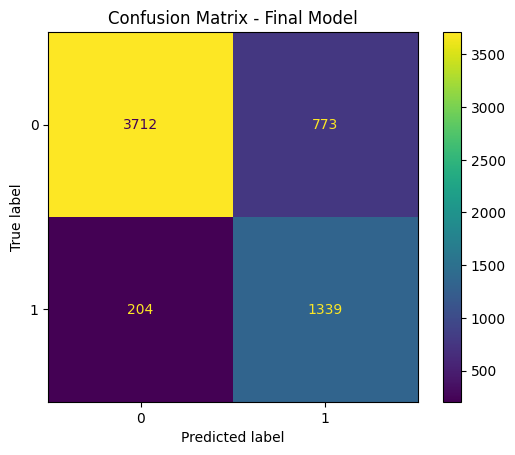

In [ ]:
# Confusion MAtrix and Classification Report for final model
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Predictions
y_pred = final_best_model.predict(X_test)

# Classification Report as DataFrame
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

print("\nClassification Report:")
print(report_df)

# plot confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Final Model")
plt.show()

In [77]:
# Saving the model as .pkl
import joblib

joblib.dump(final_best_model, "final_best_model.pkl")

['final_best_model.pkl']